In [4]:
import os, sys

IS_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IS_COLAB:
    # Pin compatible versions and upgrade torchao to fix PEFT compatibility
    os.system('pip install -q numpy pyarrow transformers==4.44.0 datasets==2.19.0 peft==0.12.0 accelerate==0.33.0 torchao==0.16.0 python-dotenv')
    os.system('nvidia-smi')
    print('Packages installed. IMPORTANT: Go to Runtime → Restart session, then re-run all cells.')
else:
    print('Running locally — skipping pip install and nvidia-smi')


Packages installed. IMPORTANT: Go to Runtime → Restart session, then re-run all cells.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Option A: Upload unified_biology_dataset_v2.json manually to /content/data/unified_biology_dataset_v2.json
# Option B: Clone repo from GitHub
# !git clone https://github.com/<your-repo>/EduHinglish.git
import os
from dotenv import load_dotenv

# Load environment variables from .env in your Google Drive
load_dotenv('/content/drive/MyDrive/EduHinglish/.env')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


True

In [2]:
import json
import random
from pathlib import Path
from collections import Counter
from transformers import AutoTokenizer
from datasets import Dataset, DatasetDict

# ── Option B: Continue training from existing fine-tuned muril_intent_v1 ──────
# Upload muril_models/muril_intent_v1/ from your Mac to Google Drive at:
#   MyDrive/EduHinglish/muril_models/muril_intent_v1/
DATASET_PATH      = Path("/content/drive/MyDrive/EduHinglish/data/unified_biology_dataset_v2.json")
INTENT_OUTPUT_DIR = Path("/content/muril_intent_dataset_v2")
# Point to the already fine-tuned model in Drive (no HuggingFace download needed)
MODEL_NAME        = "/content/drive/MyDrive/EduHinglish/muril_models/muril_intent_v1"
MAX_LENGTH        = 128
SEED              = 42

INTENT_LABEL2ID = {
    "explain_concept": 0, "compare_concepts": 1, "give_example": 2,
    "formula_request": 3, "definition": 4
}
INTENT_ID2LABEL = {v: k for k, v in INTENT_LABEL2ID.items()}
INTENT_LABELS   = list(INTENT_LABEL2ID.keys())

print(f"Loading tokenizer from: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded.")

print("Loading dataset...")
with open(DATASET_PATH, encoding="utf-8") as f:
    dataset = json.load(f)
print(f"Dataset loaded: {len(dataset)} total entries")

queries = [e for e in dataset if e.get("is_student_query") and e.get("intent") in INTENT_LABELS]
print(f"Student query entries with valid intent: {len(queries)}")

all_examples  = []
intent_counter = Counter()

for entry in queries:
    hinglish = entry.get("hinglish_roman", "")
    intent   = entry["intent"]
    if not hinglish: continue

    tokenized = tokenizer(hinglish, max_length=MAX_LENGTH, truncation=True, padding=False)
    all_examples.append({
        "input_ids":      tokenized["input_ids"],
        "attention_mask": tokenized["attention_mask"],
        "labels":         INTENT_LABEL2ID[intent]
    })
    intent_counter[intent] += 1

random.seed(SEED)
random.shuffle(all_examples)
cut = max(1, int(len(all_examples) * 0.8))
train_examples, dev_examples = all_examples[:cut], all_examples[cut:]

def _to_dataset(examples):
    return Dataset.from_dict({
        "input_ids":      [e["input_ids"]      for e in examples],
        "attention_mask": [e["attention_mask"] for e in examples],
        "labels":         [e["labels"]         for e in examples]
    })

ds = DatasetDict({"train": _to_dataset(train_examples), "dev": _to_dataset(dev_examples)})
INTENT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ds.save_to_disk(str(INTENT_OUTPUT_DIR))

# Compute class weights for imbalanced intent distribution
total    = sum(intent_counter.values())
n_classes = len(INTENT_LABELS)
class_weights = {}
for intent in INTENT_LABELS:
    count = intent_counter.get(intent, 1)
    class_weights[intent] = round(total / (n_classes * count), 4)

maps = {"intent2id": INTENT_LABEL2ID, "id2intent": {str(k): v for k, v in INTENT_ID2LABEL.items()}, "class_weights": class_weights}
with open(INTENT_OUTPUT_DIR / "label_maps.json", "w") as f:
    json.dump(maps, f)

print(f"Train: {len(train_examples)} | Dev: {len(dev_examples)}")
print(f"Intent distribution: {dict(intent_counter)}")
print(f"Class weights: {class_weights}")
print(f"Prepared Intent data saved to {INTENT_OUTPUT_DIR}")


Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Saving the dataset (0/1 shards):   0%|          | 0/96 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/24 [00:00<?, ? examples/s]

Prepared Intent data saved to /content/muril_intent_dataset_v2


In [3]:
import torch
import torch.nn as nn
import numpy as np
from transformers import AutoModelForSequenceClassification, DataCollatorWithPadding, Trainer, TrainingArguments
from datasets import load_from_disk

ds = load_from_disk(str(INTENT_OUTPUT_DIR))
train_ds, dev_ds = ds["train"], ds["dev"]
print(f"Train size: {len(train_ds)} | Dev size: {len(dev_ds)}")

# ── Option B: Load the already fine-tuned model — no LoRA needed ─────────────
# The model already has the sequence classification head trained for intent detection
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    id2label=INTENT_ID2LABEL,
    label2id=INTENT_LABEL2ID,
    ignore_mismatched_sizes=True,
)
print(f"Loaded model: {MODEL_NAME}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Get class weights list ordered by label id
weights_list = [class_weights.get(INTENT_ID2LABEL[i], 1.0) for i in range(len(INTENT_LABEL2ID))]

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = torch.tensor(class_weights, dtype=torch.float32) if class_weights else None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device) if self.class_weights is not None else None)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# ── Lower LR for continued training (avoid catastrophic forgetting) ───────────
training_args = TrainingArguments(
    output_dir="/content/muril_intent_v2_checkpoints",
    num_train_epochs=10,                 # fewer epochs — model already knows intent patterns
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=5e-5,                  # lower LR for fine-tuning from checkpoint
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=5,
    fp16=torch.cuda.is_available(),
    report_to="none",
    save_total_limit=2,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True, max_length=128)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=-1)
    accuracy = (preds == labels).mean() * 100

    per_class, f1s = {}, []
    for class_id in range(len(INTENT_LABEL2ID)):
        intent_name = INTENT_ID2LABEL[class_id]
        tp = int(((preds == class_id) & (labels == class_id)).sum())
        fp = int(((preds == class_id) & (labels != class_id)).sum())
        fn = int(((preds != class_id) & (labels == class_id)).sum())

        precision = (tp / (tp + fp) * 100) if (tp + fp) > 0 else 0.0
        recall    = (tp / (tp + fn) * 100) if (tp + fn) > 0 else 0.0
        f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
        per_class[intent_name] = {"precision": precision, "recall": recall, "f1": f1, "support": tp + fn}
        f1s.append(f1)

    return {"accuracy": accuracy, "f1_macro": np.mean(f1s), "per_class": per_class}

trainer = WeightedTrainer(
    class_weights=weights_list,
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
print("Trainer ready. Run trainer.train() in the next cell.")


pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:488: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [4]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2888: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Per Class
1,1.611500,1.609116,20.833333,6.896552,"{'explain_concept': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 10}, 'compare_concepts': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 4}, 'give_example': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 3}, 'formula_request': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2}, 'definition': {'precision': 20.833333333333336, 'recall': 100.0, 'f1': 34.48275862068966, 'support': 5}}"
2,1.608500,1.609648,16.666667,5.714286,"{'explain_concept': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 10}, 'compare_concepts': {'precision': 16.666666666666664, 'recall': 100.0, 'f1': 28.57142857142857, 'support': 4}, 'give_example': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 3}, 'formula_request': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2}, 'definition': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 5}}"
3,1.610400,1.610218,16.666667,5.714286,"{'explain_concept': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 10}, 'compare_concepts': {'precision': 16.666666666666664, 'recall': 100.0, 'f1': 28.57142857142857, 'support': 4}, 'give_example': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 3}, 'formula_request': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2}, 'definition': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 5}}"
4,1.603700,1.610879,16.666667,5.714286,"{'explain_concept': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 10}, 'compare_concepts': {'precision': 16.666666666666664, 'recall': 100.0, 'f1': 28.57142857142857, 'support': 4}, 'give_example': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 3}, 'formula_request': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2}, 'definition': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 5}}"
5,1.599200,1.611014,16.666667,5.714286,"{'explain_concept': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 10}, 'compare_concepts': {'precision': 16.666666666666664, 'recall': 100.0, 'f1': 28.57142857142857, 'support': 4}, 'give_example': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 3}, 'formula_request': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2}, 'definition': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 5}}"
6,1.613000,1.612339,16.666667,5.714286,"{'explain_concept': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 10}, 'compare_concepts': {'precision': 16.666666666666664, 'recall': 100.0, 'f1': 28.57142857142857, 'support': 4}, 'give_example': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 3}, 'formula_request': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2}, 'definition': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 5}}"
7,1.596700,1.612590,16.666667,5.714286,"{'explain_concept': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 10}, 'compare_concepts': {'precision': 16.666666666666664, 'recall': 100.0, 'f1': 28.57142857142857, 'support': 4}, 'give_example': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 3}, 'formula_request': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2}, 'definition': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 5}}"
8,1.608600,1.607369,16.666667,5.714286,"{'explain_concept': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 10}, 'compare_concepts': {'precision': 16.666666666666664, 'recall': 100.0, 'f1': 28.57142857142857, 'support': 4}, 'give_example': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 3}, 'formula_request': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2}, 'definition': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 5}}"
9,1.576500,1.602947,16.666667,5.714286,"{'explain_concept': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 10}, 'compare_concepts': {'precision': 16.666666666666664, 'recall': 100.0, 'f1': 28.57142857142857, 'support': 4}, 'give_ex

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2888: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2888: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2888: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2888: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/usr

TrainOutput(global_step=240, training_loss=1.5231029530366262, metrics={'train_runtime': 35.3437, 'train_samples_per_second': 54.324, 'train_steps_per_second': 6.79, 'total_flos': 25730640921024.0, 'train_loss': 1.5231029530366262, 'epoch': 20.0})

In [5]:
eval_result = trainer.evaluate()
print(f"Accuracy: {eval_result['eval_accuracy']:.2f}%")
print(f"F1 Macro: {eval_result['eval_f1_macro']:.2f}%")

per_class = eval_result.get("eval_per_class", {})
print("Per-intent metrics:")
print(f"{'Intent':>18s} | {'Prec':>8s} | {'Recall':>8s} | {'F1':>8s} | {'N':>5s}")
for intent_name in INTENT_LABELS:
    m = per_class.get(intent_name, {})
    if m:
        print(f"{intent_name:>18s} | {m.get('precision', 0):>7.1f}% | {m.get('recall', 0):>7.1f}% | {m.get('f1', 0):>7.1f}% | {m.get('support', 0):>5d}")

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2888: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Accuracy: 20.83%
F1 Macro: 9.77%
Per-intent metrics:
            Intent |     Prec |   Recall |       F1 |     N
   explain_concept |    16.7% |    10.0% |    12.5% |    10
  compare_concepts |    22.2% |   100.0% |    36.4% |     4
      give_example |     0.0% |     0.0% |     0.0% |     3
   formula_request |     0.0% |     0.0% |     0.0% |     2
        definition |     0.0% |     0.0% |     0.0% |     5


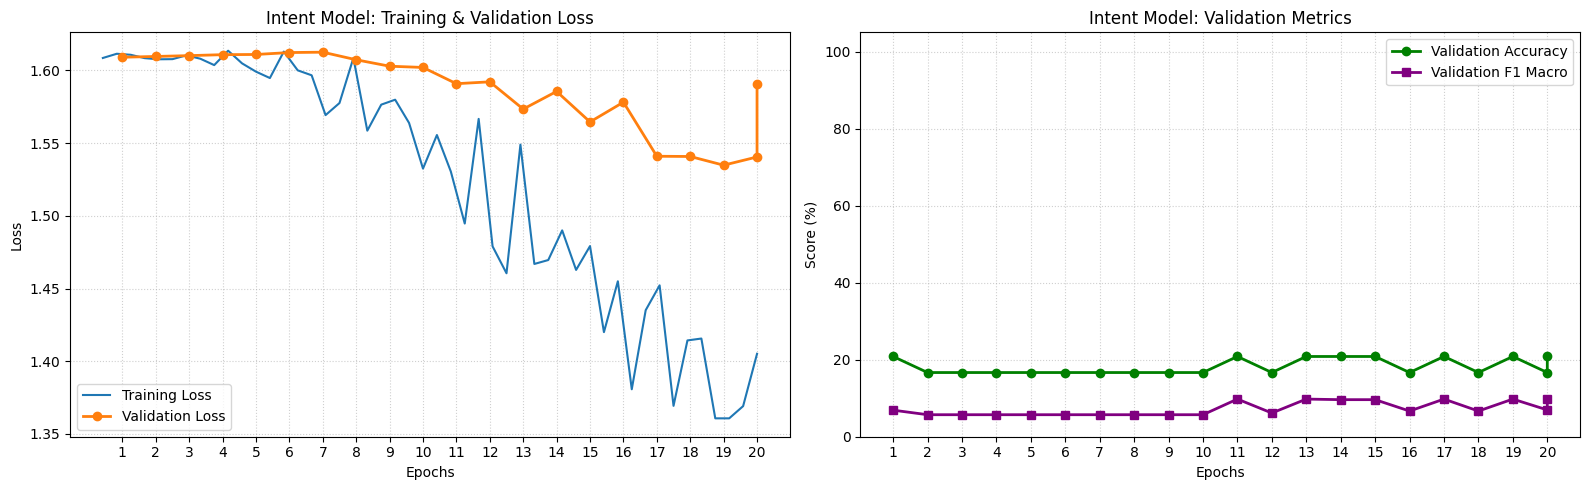

In [6]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

# 1. Extract loss/accuracy/F1 using 'epoch' instead of 'step'
train_loss = [log['loss'] for log in log_history if 'loss' in log]
train_epochs = [log['epoch'] for log in log_history if 'loss' in log]

eval_loss = [log['eval_loss'] for log in log_history if 'eval_loss' in log]
eval_epochs = [log['epoch'] for log in log_history if 'eval_loss' in log]
eval_acc = [log['eval_accuracy'] for log in log_history if 'eval_accuracy' in log]
eval_f1 = [log['eval_f1_macro'] for log in log_history if 'eval_f1_macro' in log]

# 2. Automatically find total epochs trained (e.g., 20)
max_epoch = int(max(eval_epochs)) if eval_epochs else 20
epoch_ticks = range(1, max_epoch + 1)

# 3. Setup plotting
plt.figure(figsize=(16, 5))

# --- Subplot 1: Training & Validation Loss ---
plt.subplot(1, 2, 1)
plt.plot(train_epochs, train_loss, label='Training Loss', color='#1f77b4', linewidth=1.5)
if eval_loss:
    plt.plot(eval_epochs, eval_loss, label='Validation Loss', color='#ff7f0e', marker='o', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Intent Model: Training & Validation Loss')
plt.xticks(epoch_ticks)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# --- Subplot 2: Validation Metrics (Accuracy & Macro F1) ---
plt.subplot(1, 2, 2)
if eval_acc:
    plt.plot(eval_epochs, eval_acc, label='Validation Accuracy', color='green', marker='o', linewidth=2)
if eval_f1:
    plt.plot(eval_epochs, eval_f1, label='Validation F1 Macro', color='purple', marker='s', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Score (%)')
plt.title('Intent Model: Validation Metrics')
plt.xticks(epoch_ticks)
plt.ylim(bottom=0, top=105) # Keeps the y-axis perspective clear
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [7]:
import os

# ── Option B: No LoRA merge needed — save model directly ─────────────────────
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/EduHinglish/muril_models/muril_intent_v2"
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

model.save_pretrained(DRIVE_OUTPUT_DIR)
tokenizer.save_pretrained(DRIVE_OUTPUT_DIR)
print(f"Model saved to Google Drive: {DRIVE_OUTPUT_DIR}")
print("Download muril_intent_v2/ from Drive to your local muril_models/ folder.")


Model saved to /content/drive/MyDrive/EduHinglish/models/muril_intent_v2


In [9]:
INTENT_TESTS = [
    ("Sir, nucleus ka kaam kya hota hai?",           "explain_concept"),
    ("Mitochondria aur chloroplast mein kya fark hai?", "compare_concepts"),
    ("Ek example do osmosis ka?",                    "give_example"),
    ("Photosynthesis ki definition kya hai?",        "definition"),
    ("Mendel ke laws ka formula kya hai?",           "formula_request"),
]

model.eval()
print("── MuRIL Intent Predictions ──")
for sent, expected in INTENT_TESTS:
    print(f'Input: "{sent}"')
    inputs = tokenizer(sent, return_tensors="pt", truncation=True, max_length=128).to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs   = torch.nn.functional.softmax(outputs.logits, dim=-1)
        conf, pred_id = torch.max(probs, dim=-1)
        pred_label = model.config.id2label.get(pred_id.item(), "O")

    marker = "✓" if pred_label == expected else "✗"
    print(f"  Predicted: {pred_label:<20} Conf: {conf.item():.2f}  {marker}")
    print()


── MuRIL Intent Predictions ──
Input: "Sir, nucleus ka kaam kya hota hai?"
  Predicted: compare_concepts (conf: 0.23)  ✗
Input: "Mitochondria aur chloroplast mein kya fark hai?"
  Predicted: compare_concepts (conf: 0.26)  ✓
Input: "Ek example do osmosis ka?"
  Predicted: compare_concepts (conf: 0.22)  ✗
